In [1]:
import numpy as np
import matplotlib.pyplot as plt
from FastBEMT import BEMT, Environment, Propeller, Simulation
from FastBEMT.Utils import BladeStressCalculator, Plotter, load_propeller_dict
import scienceplots
from PIL import Image
import os
plt.style.use(['science','no-latex'])

propellers_list = load_propeller_dict('Optimization Results/SMS-EMOA/Parametric/Multipoint/run_002')
# propellers_list = load_propeller_dict('Data/10x7E')
print(f'Loaded {len(propellers_list)} propellers')

rpm = 7000
environment = Environment(
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    p_ref=2e-5,
)
simulation = Simulation(
    revolutions=5,
    timesteps_per_revolution=100,
    device='cuda',
)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\PusinoDavide\\FastBEMT\\Datasets\\Optimization Results\\SMS-EMOA\\Parametric\\Multipoint\\run_002.pkl'

C:\Users\Davide Pusino\AppData\Local\Temp\ipykernel_1592\4113871493.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


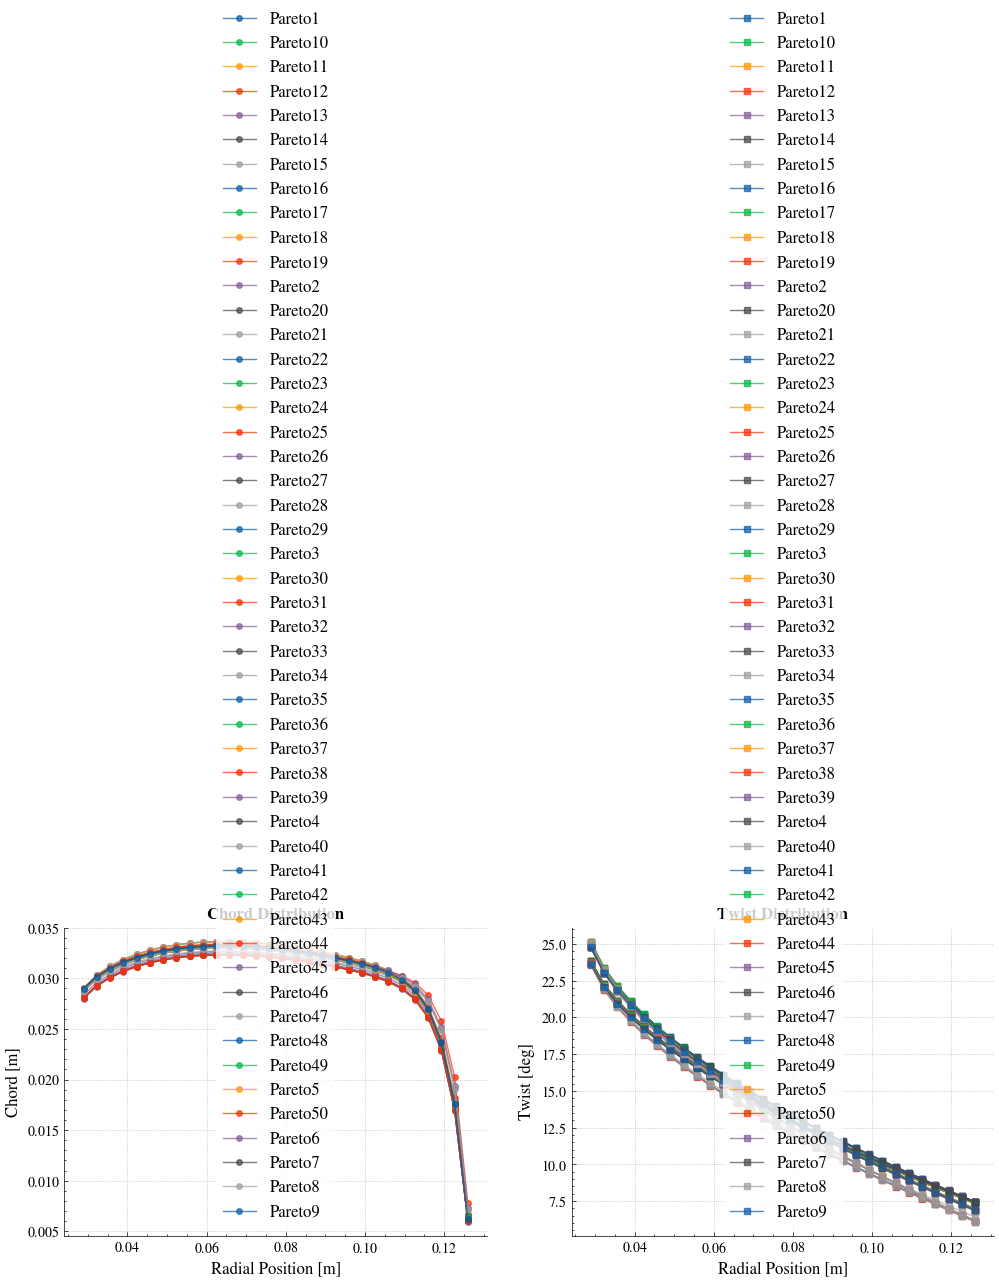

In [ ]:
# Plot twist and chord distributions for all propellers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for idx, (propeller_name, blade_dict) in enumerate(propellers_list):
    r = blade_dict['r']
    chord = blade_dict['chord']
    twist = blade_dict['twist']
    
    # Plot chord distribution
    ax1.plot(r, chord, marker='o', markersize=4, label=propeller_name, alpha=0.7)
    
    # Plot twist distribution
    ax2.plot(r, twist, marker='s', markersize=4, label=propeller_name, alpha=0.7)

# Configure chord plot
ax1.set_xlabel('Radial Position [m]', fontsize=12)
ax1.set_ylabel('Chord [m]', fontsize=12)
ax1.set_title('Chord Distribution', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=1.0, linestyle=':')
ax1.legend(frameon=True, edgecolor='none', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(top=False, right=False, which='both')

# Configure twist plot
ax2.set_xlabel('Radial Position [m]', fontsize=12)
ax2.set_ylabel('Twist [deg]', fontsize=12)
ax2.set_title('Twist Distribution', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=1.0, linestyle=':')
ax2.legend(frameon=True, edgecolor='none', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(top=False, right=False, which='both')

plt.tight_layout()
plt.show()


Processing Pareto1...


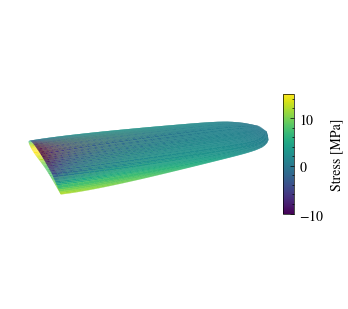


Processing Pareto10...


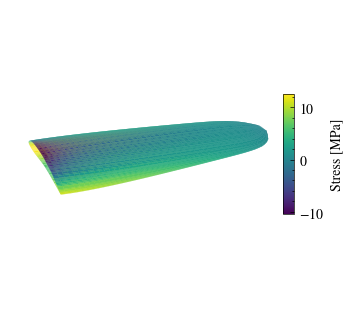


Processing Pareto11...


KeyboardInterrupt: 

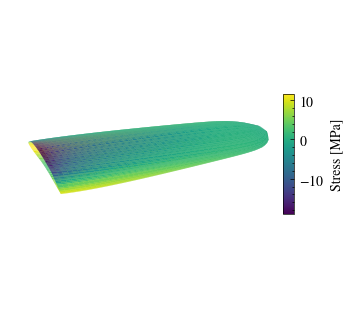

In [ ]:
# Process all propellers
for idx, (propeller_name, blade_dict) in enumerate(propellers_list):
    print(f'\nProcessing {propeller_name}...')
    
    # Create propeller instance
    propeller = Propeller(
        geometry=blade_dict,
        environment=environment,
        simulation=simulation,
    )
    v_inf = 0
    bemt = BEMT(propeller=propeller, environment=environment, rpm=rpm, v_inf=v_inf)
    bemt.compute_total_forces()
    
    # Calculate stresses
    stress_calc = BladeStressCalculator(propeller=propeller)
    sigma_c, sigma_b = stress_calc.blade_stress_report(material_rho=2700, bemt=bemt, show=False)
    
    # Use plotter to visualize stress distribution
    plotter = Plotter(propeller)
    temp_path = f'../Figures/Blade Renderings/{propeller_name}_stress_temp.png'
    final_path = f'../Figures/Blade Renderings/{propeller_name}_stress.png'
    plotter.plot_stress_distribution(
        sigma_c=sigma_c,
        sigma_b=sigma_b,
        stress_calculator=stress_calc,
        figsize=(4.5, 3),
        cmap='viridis',
        save_path=temp_path
    )
    
    # Crop whitespace using PIL
    img = Image.open(temp_path)
    img_array = np.array(img)
    
    # Find non-white pixels (allowing for slight variations)
    if img_array.shape[2] == 4:  # RGBA
        non_white = np.any(img_array[:, :, :3] < 250, axis=2)
    else:  # RGB
        non_white = np.any(img_array < 250, axis=2)
    
    rows = np.any(non_white, axis=1)
    cols = np.any(non_white, axis=0)
    
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    
    # Crop and save
    cropped_img = img.crop((x_min, y_min, x_max + 1, y_max + 1))
    cropped_img.save(final_path, dpi=(200, 200))
    
    # Clean up temp file
    os.remove(temp_path)
    
print('\nAll propellers processed!')